# Fruit & Vegetable Disease Classifier — Full Pipeline

Run the cells top-to-bottom once per experiment:

| Step | What it does |
|------|--------------|
| 1 | **Config** — paths and hyper-parameters |
| 2 | **Label generation** — colour / size labels saved to `labels.csv` |
| 3 | **Size-threshold check** — verify `SMALL_THRESHOLD` / `LARGE_THRESHOLD` |
| 4 | **Preprocessing** — load images, encode labels, train/val/test split |
| 5 | **Train CNN** — multi-head model for condition, colour, and size |
| 6 | **Evaluate** — classification reports and confusion matrices |

## Step 1 — Config

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import random
import logging
from sklearn.cluster import KMeans
from IPython.display import Image as IPImage, display
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
import matplotlib.pyplot as plt


# ---- PATHS ----
DATASET_PATH = os.environ.get(
    "FRUIT_DATASET_PATH",
    r"C:\Users\fihab\Documents\Fruit And Vegetable Diseases Dataset",
)
OUTPUT_CSV = "labels.csv"

# ---- LABEL GENERATION ----
SAMPLE_SIZE = 16
GRID_COLS   = 4
THUMB_SIZE  = (200, 200)

# Foreground pixel area thresholds.
# Re-run Step 3 (size-threshold check) after first labelling and update here if needed.
SMALL_THRESHOLD = 50_176
LARGE_THRESHOLD = 164_462

# ---- PREPROCESSING ----
IMG_SIZE  = (224, 224)
TEST_SIZE = 0.10
VAL_SIZE  = 0.10

# ---- TRAINING ----
EPOCHS     = 20
BATCH_SIZE = 32
LR         = 0.001

## Step 2 — Label Generation

Walks the dataset folders, infers **colour** and **size** for every image, and writes `labels.csv`.
A visual verification grid is saved to `label_verification_grid.png`.

  Processed 500 images...
  Processed 1000 images...
  Processed 1500 images...
  Processed 2000 images...
  Processed 2500 images...
  Processed 3000 images...
  Processed 3500 images...
  Processed 4000 images...
  Processed 4500 images...
  Processed 5000 images...
  Processed 5500 images...
  Processed 6000 images...
  Processed 6500 images...
  Processed 7000 images...
  Processed 7500 images...
  Processed 8000 images...
  Processed 8500 images...
  Processed 9000 images...
  Processed 9500 images...
  Processed 10000 images...
  Processed 10500 images...
  Processed 11000 images...
  Processed 11500 images...
  Processed 12000 images...
  Processed 12500 images...
  Processed 13000 images...
  Processed 13500 images...
  Processed 14000 images...
  Processed 14500 images...
  Processed 15000 images...
  Processed 15500 images...
  Processed 16000 images...
  Processed 16500 images...
  Processed 17000 images...
  Processed 17500 images...
  Processed 18000 images...
  Processed 

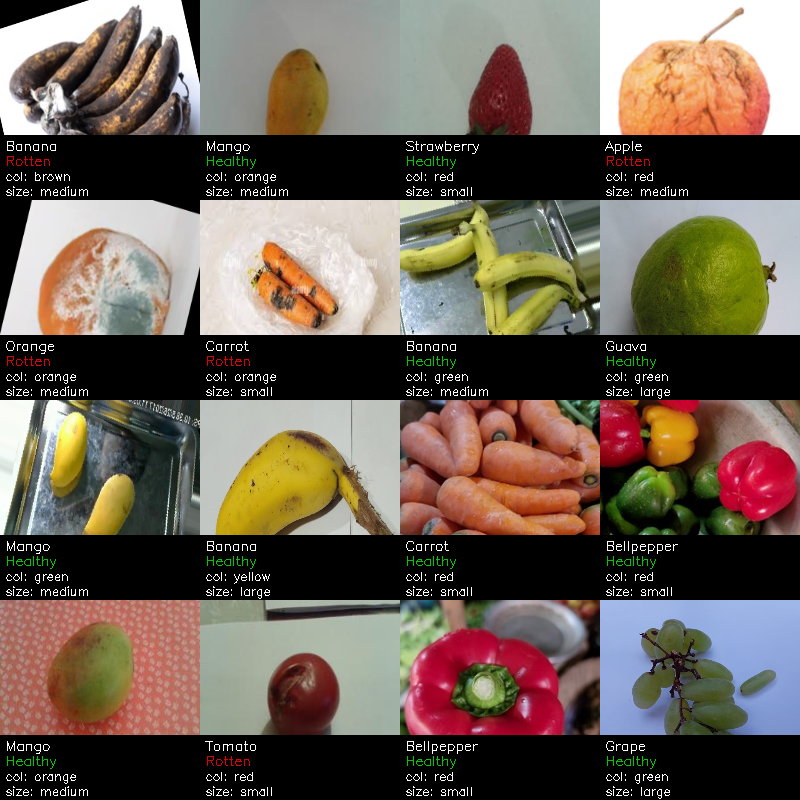

In [ ]:


logging.basicConfig(
    level=logging.DEBUG,
    format="%(levelname)s: %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler("labeling.log", encoding="utf-8"),
    ],
)
logging.getLogger().handlers[0].setLevel(logging.WARNING)
log = logging.getLogger(__name__)


def get_foreground_mask(image, corner_size=10, bg_tol=30):
    h, w = image.shape[:2]
    corners = np.vstack([
        image[:corner_size,   :corner_size ].reshape(-1, 3),
        image[:corner_size,   w-corner_size:].reshape(-1, 3),
        image[h-corner_size:, :corner_size ].reshape(-1, 3),
        image[h-corner_size:, w-corner_size:].reshape(-1, 3),
    ])
    bg_color = np.median(corners, axis=0)
    diff = np.abs(image.astype(np.int32) - bg_color.astype(np.int32))
    dist = np.max(diff, axis=2).astype(np.uint8)
    _, mask = cv2.threshold(dist, bg_tol, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


_COLOUR_RANGES = {
    "red":    [((0, 70, 50),    (10, 255, 255)), ((170, 70, 50), (180, 255, 255))],
    # Orange ends at H=17 so banana yellow (H≈18-28) is not pulled into orange.
    "orange": [((10, 100, 100), (17, 255, 255))],
    # Yellow ends at H=29 so yellow-green grapes are not caught as yellow.
    "yellow": [((18, 60, 100),  (29, 255, 255))],
    # Green starts at H=30 to capture yellow-green grapes and limes.
    "green":  [((30, 40, 40),   (85, 255, 255))],
    "brown":  [((5, 30, 20),    (22, 150, 150))],
    "purple": [((125, 40, 40),  (155, 255, 255))],
    "white":  [((0, 0, 180),    (180, 40, 255))],
}


def bgr_to_colour_name(bgr_pixel):
    pixel = np.uint8([[bgr_pixel]])
    h, s, v = cv2.cvtColor(pixel, cv2.COLOR_BGR2HSV)[0, 0]
    for name, ranges in _COLOUR_RANGES.items():
        for (hl, sl, vl), (hu, su, vu) in ranges:
            if hl <= h <= hu and sl <= s <= su and vl <= v <= vu:
                return name
    return "unknown"


def _hsv_range_vote(image, fg_mask):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    best_colour, best_count = "unknown", 0
    for colour_name, ranges in _COLOUR_RANGES.items():
        mask = None
        for lower, upper in ranges:
            m = cv2.inRange(hsv, np.array(lower), np.array(upper))
            mask = m if mask is None else cv2.bitwise_or(mask, m)
        count = cv2.countNonZero(cv2.bitwise_and(mask, fg_mask))
        if count > best_count:
            best_count, best_colour = count, colour_name
    return best_colour


def get_dominant_colour(image, n_clusters=3, min_cluster_frac=0.10):
    """Pick the most saturated foreground cluster — not the largest.

    This stops white background bleed and specular highlights (both near-zero
    saturation) from overriding the fruit's actual colour.
    """
    fg_mask = get_foreground_mask(image)
    pixels = image[fg_mask == 255].reshape(-1, 3).astype(np.float32)
    if len(pixels) < n_clusters:
        return _hsv_range_vote(image, fg_mask)
    km = KMeans(n_clusters=n_clusters, n_init=3, random_state=0)
    km.fit(pixels)
    counts = np.bincount(km.labels_)
    centroids_bgr = km.cluster_centers_.astype(np.uint8)
    centroids_hsv = cv2.cvtColor(
        centroids_bgr.reshape(1, -1, 3), cv2.COLOR_BGR2HSV
    ).reshape(-1, 3)
    min_count = max(1, int(min_cluster_frac * len(pixels)))
    for idx in np.argsort(centroids_hsv[:, 1])[::-1]:
        if counts[idx] >= min_count:
            name = bgr_to_colour_name(centroids_bgr[idx])
            if name != "unknown":
                return name
    return _hsv_range_vote(image, fg_mask)


def get_size(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    area = cv2.countNonZero(thresh)
    if area < SMALL_THRESHOLD:
        return "small"
    elif area > LARGE_THRESHOLD:
        return "large"
    return "medium"


def draw_label(image, fruit, condition, colour, size):
    img = cv2.resize(image, THUMB_SIZE)
    cv2.rectangle(img, (0, THUMB_SIZE[1] - 65), (THUMB_SIZE[0], THUMB_SIZE[1]), (0, 0, 0), -1)
    cond_colour = (0, 200, 0) if condition.lower() == "healthy" else (0, 0, 220)
    cv2.putText(img, f"{fruit}",        (5, THUMB_SIZE[1] - 50), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
    cv2.putText(img, f"{condition}",    (5, THUMB_SIZE[1] - 35), cv2.FONT_HERSHEY_SIMPLEX, 0.45, cond_colour,     1)
    cv2.putText(img, f"col: {colour}",  (5, THUMB_SIZE[1] - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4,  (255, 255, 255), 1)
    cv2.putText(img, f"size: {size}",   (5, THUMB_SIZE[1] - 5),  cv2.FONT_HERSHEY_SIMPLEX, 0.4,  (255, 255, 255), 1)
    return img


def build_grid(thumbnails):
    rows = []
    for i in range(0, len(thumbnails), GRID_COLS):
        row_imgs = thumbnails[i:i + GRID_COLS]
        while len(row_imgs) < GRID_COLS:
            row_imgs.append(np.zeros((THUMB_SIZE[1], THUMB_SIZE[0], 3), dtype=np.uint8))
        rows.append(np.hstack(row_imgs))
    return np.vstack(rows)


# ---- MAIN LOOP ----
records      = []
images_cache = []
skipped      = 0
total_seen   = 0

for folder_name in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue
    if "__" not in folder_name:
        log.warning(f"Skipping unrecognised folder: {folder_name}")
        continue

    parts     = folder_name.split("__")
    fruit     = parts[0]
    condition = parts[1]

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        total_seen += 1
        img_path = os.path.join(folder_path, filename)
        image = cv2.imread(img_path)
        if image is None:
            log.warning(f"Could not read: {img_path}")
            skipped += 1
            continue

        colour = get_dominant_colour(image)
        size   = get_size(image)
        records.append({"image_path": img_path, "fruit": fruit,
                         "condition": condition, "colour": colour, "size": size})
        images_cache.append(image)
        log.debug(f"[{fruit} | {condition}] {filename} → colour: {colour}, size: {size}")

        if total_seen % 500 == 0:
            print(f"  Processed {total_seen} images...")

print(f"\nDone. Processed {len(records)} images, skipped {skipped}.")

pd.DataFrame(records).to_csv(OUTPUT_CSV, index=False)
print(f"Labels saved to {OUTPUT_CSV}")

sample_indices = random.sample(range(len(records)), min(SAMPLE_SIZE, len(records)))
thumbnails = [
    draw_label(images_cache[i], records[i]["fruit"], records[i]["condition"],
               records[i]["colour"], records[i]["size"])
    for i in sample_indices
]
grid = build_grid(thumbnails)
cv2.imwrite("label_verification_grid.png", grid)
display(IPImage("label_verification_grid.png"))

## Step 3 — Size-Threshold Check

Computes the 25th / 75th percentile of foreground pixel areas across the dataset and recommends values for `SMALL_THRESHOLD` / `LARGE_THRESHOLD` in Step 1.
Update those constants and re-run from Step 2 if the recommended values differ significantly.

0/29277...
1000/29277...
2000/29277...
3000/29277...
4000/29277...
5000/29277...
6000/29277...
7000/29277...
8000/29277...
9000/29277...
10000/29277...
11000/29277...
12000/29277...
13000/29277...
14000/29277...
15000/29277...
16000/29277...
17000/29277...
18000/29277...
19000/29277...
20000/29277...
21000/29277...
22000/29277...
23000/29277...
24000/29277...
25000/29277...
26000/29277...
27000/29277...
28000/29277...
29000/29277...

--- Area statistics per size class ---
          count          mean           std       min        25%       50%         75%         max
size                                                                                              
large    7319.0  2.927481e+06  3.960428e+06  164488.0  203532.00  425076.0  5574947.00  25511058.0
medium  14700.0  8.597722e+04  3.852574e+04   50176.0   50176.00   78400.0   119827.25    164462.0
small    7258.0  3.955318e+04  1.566426e+04    5790.0   32221.75   48926.0    50155.00     50175.0

Recommended thresholds:
  S

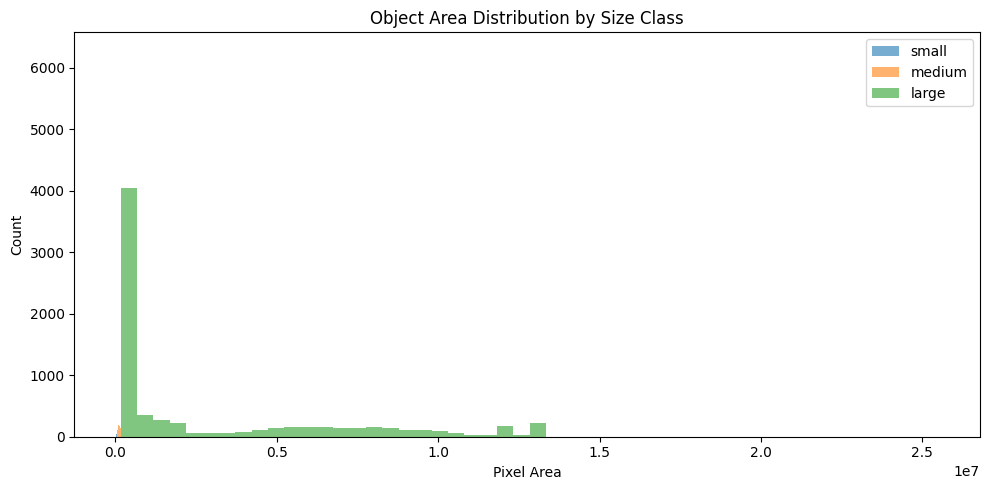

In [ ]:
%matplotlib inline

df_labels = pd.read_csv(OUTPUT_CSV)
total     = len(df_labels)

areas      = []
size_lbls  = []

for i, row in df_labels.iterrows():
    if i % 1000 == 0:
        print(f"{i}/{total}...")
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    areas.append(cv2.countNonZero(thresh))
    size_lbls.append(row["size"])

df_areas = pd.DataFrame({"area": areas, "size": size_lbls})

print("\n--- Area statistics per size class ---")
print(df_areas.groupby("size")["area"].describe().to_string())

all_areas = np.array(areas)
p25 = int(np.percentile(all_areas, 25))
p75 = int(np.percentile(all_areas, 75))
print(f"\nRecommended thresholds:")
print(f"  SMALL_THRESHOLD = {p25}  (current: {SMALL_THRESHOLD})")
print(f"  LARGE_THRESHOLD = {p75}  (current: {LARGE_THRESHOLD})")

fig, ax = plt.subplots(figsize=(10, 5))
for size_label in ["small", "medium", "large"]:
    subset = df_areas[df_areas["size"] == size_label]["area"]
    if len(subset):
        ax.hist(subset, bins=50, alpha=0.6, label=size_label)
ax.set_xlabel("Pixel Area")
ax.set_ylabel("Count")
ax.set_title("Object Area Distribution by Size Class")
ax.legend()
plt.tight_layout()
plt.savefig("area_distribution.png", dpi=150)
plt.show()

## Step 4 — Preprocessing

Loads every image from `labels.csv`, resizes to `IMG_SIZE`, normalises to `[0, 1]`, encodes labels, and saves train / val / test splits as `.npy` files.

In [ ]:

df = pd.read_csv(OUTPUT_CSV)
print(f"Total images: {len(df)}\n")

images = []
failed = []
total  = len(df)

print("Loading images...")
for i, img_path in enumerate(df["image_path"]):
    if i % 500 == 0:
        print(f"  {i}/{total} images loaded...")
    img = cv2.imread(img_path)
    if img is None:
        print(f"  [WARNING] Could not read: {img_path}")
        failed.append(i)
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    images.append(img)

if failed:
    failed_paths = df.iloc[failed]["image_path"].tolist()
    print(f"\n[WARNING] {len(failed)} images failed to load and were skipped.")
    with open("failed_images.log", "w", encoding="utf-8") as flog:
        flog.write("\n".join(failed_paths))
    df = df.drop(index=failed).reset_index(drop=True)

images = np.array(images, dtype=np.float32)
print(f"\nImages array shape: {images.shape}")
print(f"Estimated RAM usage: {images.nbytes / 1e9:.2f} GB")

# ---- ENCODE LABELS ----
encoders = {}
labels   = {}
for col in ["condition", "colour", "size"]:
    le = LabelEncoder()
    labels[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col} classes: {list(le.classes_)}")

# ---- SPLIT DATA ----
print("\nSplitting data...")
X_temp, X_test, \
y_cond_temp,  y_cond_test, \
y_col_temp,   y_col_test, \
y_size_temp,  y_size_test = train_test_split(
    images, labels["condition"], labels["colour"], labels["size"],
    test_size=TEST_SIZE, random_state=42
)

X_train, X_val, \
y_cond_train, y_cond_val, \
y_col_train,  y_col_val, \
y_size_train, y_size_val = train_test_split(
    X_temp, y_cond_temp, y_col_temp, y_size_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=42
)

n_total = len(X_train) + len(X_val) + len(X_test)
print(f"Training samples:   {len(X_train):>6}  ({len(X_train)/n_total*100:.1f}%)")
print(f"Validation samples: {len(X_val):>6}  ({len(X_val)/n_total*100:.1f}%)")
print(f"Test samples:       {len(X_test):>6}  ({len(X_test)/n_total*100:.1f}%)")

# ---- SAVE ----
print("\nSaving files...")
for name, arr in [
    ("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
    ("y_cond_train", y_cond_train), ("y_cond_val", y_cond_val), ("y_cond_test", y_cond_test),
    ("y_col_train",  y_col_train),  ("y_col_val",  y_col_val),  ("y_col_test",  y_col_test),
    ("y_size_train", y_size_train), ("y_size_val", y_size_val), ("y_size_test", y_size_test),
]:
    np.save(f"{name}.npy", arr)

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("\nPreprocessing complete.")

Total images: 29277

Loading images...
  0/29277 images loaded...
  500/29277 images loaded...
  1000/29277 images loaded...
  1500/29277 images loaded...
  2000/29277 images loaded...
  2500/29277 images loaded...
  3000/29277 images loaded...
  3500/29277 images loaded...
  4000/29277 images loaded...
  4500/29277 images loaded...
  5000/29277 images loaded...
  5500/29277 images loaded...
  6000/29277 images loaded...
  6500/29277 images loaded...
  7000/29277 images loaded...
  7500/29277 images loaded...
  8000/29277 images loaded...
  8500/29277 images loaded...
  9000/29277 images loaded...
  9500/29277 images loaded...
  10000/29277 images loaded...
  10500/29277 images loaded...
  11000/29277 images loaded...
  11500/29277 images loaded...
  12000/29277 images loaded...
  12500/29277 images loaded...
  13000/29277 images loaded...
  13500/29277 images loaded...
  14000/29277 images loaded...
  14500/29277 images loaded...
  15000/29277 images loaded...
  15500/29277 images loa

## Step 5 — Train CNN

Builds a shared-backbone multi-head CNN with three output heads (condition, colour, size), trains with early stopping, and saves `best_model.keras`.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ---- LOAD DATA ----
print("Loading data...")
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")

y_cond_train = np.load("y_cond_train.npy")
y_cond_val   = np.load("y_cond_val.npy")
y_col_train  = np.load("y_col_train.npy")
y_col_val    = np.load("y_col_val.npy")
y_size_train = np.load("y_size_train.npy")
y_size_val   = np.load("y_size_val.npy")

with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

n_condition = len(encoders["condition"].classes_)
n_colour    = len(encoders["colour"].classes_)
n_size      = len(encoders["size"].classes_)
print(f"Condition classes: {n_condition}")
print(f"Colour classes:    {n_colour}")
print(f"Size classes:      {n_size}")

# ---- BUILD CNN ----
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = augment(inputs)

for filters in [32, 64, 128, 256]:
    x = layers.Conv2D(filters, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
shared = layers.Dense(256, activation="relu")(x)

def head(inp, n_classes, name):
    h = layers.Dense(128, activation="relu")(inp)
    h = layers.Dropout(0.3)(h)
    return layers.Dense(n_classes, activation="softmax", name=name)(h)

cond_out = head(shared, n_condition, "condition")
col_out  = head(shared, n_colour,    "colour")
size_out = head(shared, n_size,      "size")

model = models.Model(inputs=inputs, outputs=[cond_out, col_out, size_out])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss={k: "sparse_categorical_crossentropy" for k in ["condition", "colour", "size"]},
    loss_weights={
        "condition": 2.0,
        "colour":    0.5,
        "size":      0.5,
    },
    metrics={k: "accuracy" for k in ["condition", "colour", "size"]},
)
model.summary()

# ---- TRAIN ----
print("\nStarting training...")
history = model.fit(
    X_train,
    {"condition": y_cond_train, "colour": y_col_train, "size": y_size_train},
    validation_data=(
        X_val,
        {"condition": y_cond_val, "colour": y_col_val, "size": y_size_val}
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    ],
)

model.save("fruit_model.keras")
print("\nModel saved to fruit_model.keras")

Loading data...
Condition classes: 2
Colour classes:    8
Size classes:      3


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ augmentation[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ max_pooling2d_3[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 753,613 (2.87 MB)

 Trainable params: 752,653 (2.87 MB)

 Non-trainable params: 960 (3.75 KB)


Starting training...
Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 547s 733ms/step - colour_accuracy: 0.7001 - colour_loss: 0.8071 - condition_accuracy: 0.7594 - condition_loss: 0.4937 - loss: 1.8430 - size_accuracy: 0.5659 - size_loss: 0.9039 - val_colour_accuracy: 0.7145 - val_colour_loss: 0.7446 - val_condition_accuracy: 0.7920 - val_condition_loss: 0.4494 - val_loss: 1.6952 - val_size_accuracy: 0.6195 - val_size_loss: 0.8557 - learning_rate: 0.0010
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 518s 708ms/step - colour_accuracy: 0.7504 - colour_loss: 0.6630 - condition_accuracy: 0.8509 - condition_loss: 0.3430 - loss: 1.4059 - size_accuracy: 0.6425 - size_loss: 0.7766 - val_colour_accuracy: 0.7527 - val_colour_loss: 0.6536 - val_condition_accuracy: 0.8009 - val_condition_loss: 0.4762 - val_loss: 1.6727 - val_size_accuracy: 0.6492 - val_size_loss: 0.7876 - learning_rate: 0.0010
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 1205s 2s/step - colour_accuracy: 0.7720 - colour_loss: 0.6105 - condition_accu

NameError: name 'history' is not defined

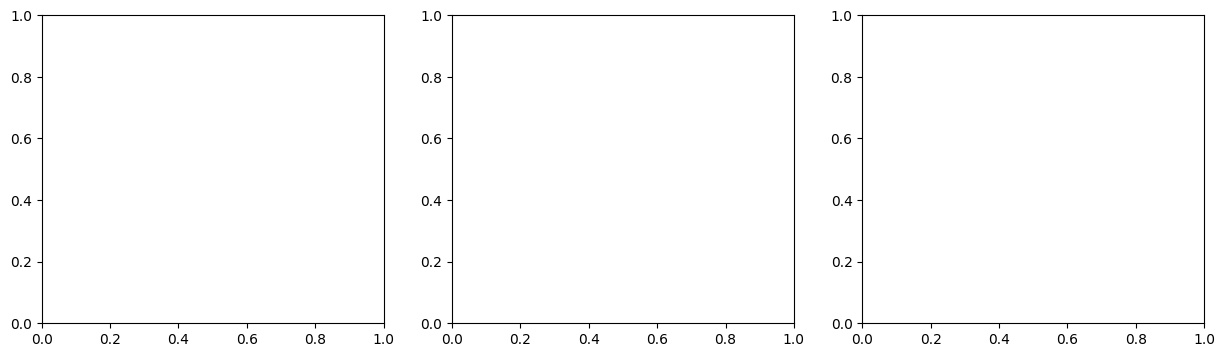

In [2]:
# ---- PLOT TRAINING HISTORY ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, task in zip(axes, ["condition", "colour", "size"]):
    ax.plot(history.history[f"{task}_accuracy"],     label="train")
    ax.plot(history.history[f"val_{task}_accuracy"], label="val")
    ax.set_title(f"{task} accuracy")
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

## Step 6 — Evaluate

Loads the best saved model, runs predictions on the held-out test set, and prints classification reports and confusion matrices.

Loading test data...
Loading model...
Running predictions on 2928 test samples...
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step

  CONDITION
              precision    recall  f1-score   support

     Healthy      0.930     0.974     0.951      1363
      Rotten      0.976     0.936     0.956      1565

    accuracy                          0.954      2928
   macro avg      0.953     0.955     0.953      2928
weighted avg      0.955     0.954     0.954      2928



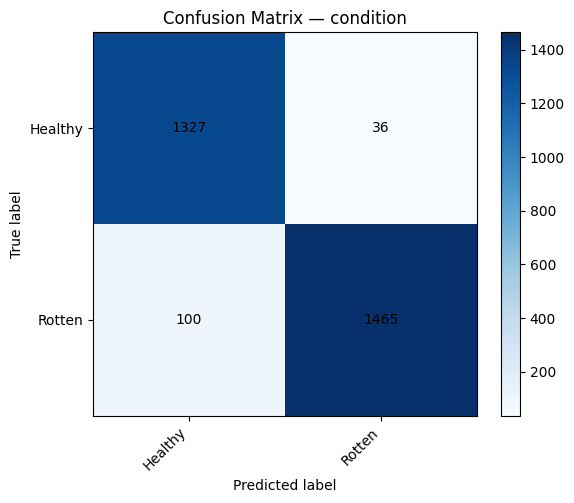


  COLOUR
              precision    recall  f1-score   support

       brown      0.674     0.681     0.677       282
       green      0.848     0.936     0.890       281
      orange      0.836     0.734     0.782       647
      purple      0.000     0.000     0.000         0
         red      0.925     0.893     0.909      1087
     unknown      0.000     0.000     0.000         0
       white      0.517     0.536     0.526        84
      yellow      0.755     0.867     0.807       547

    accuracy                          0.827      2928
   macro avg      0.569     0.581     0.574      2928
weighted avg      0.830     0.827     0.827      2928



C:\Users\fihab\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fihab\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fihab\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

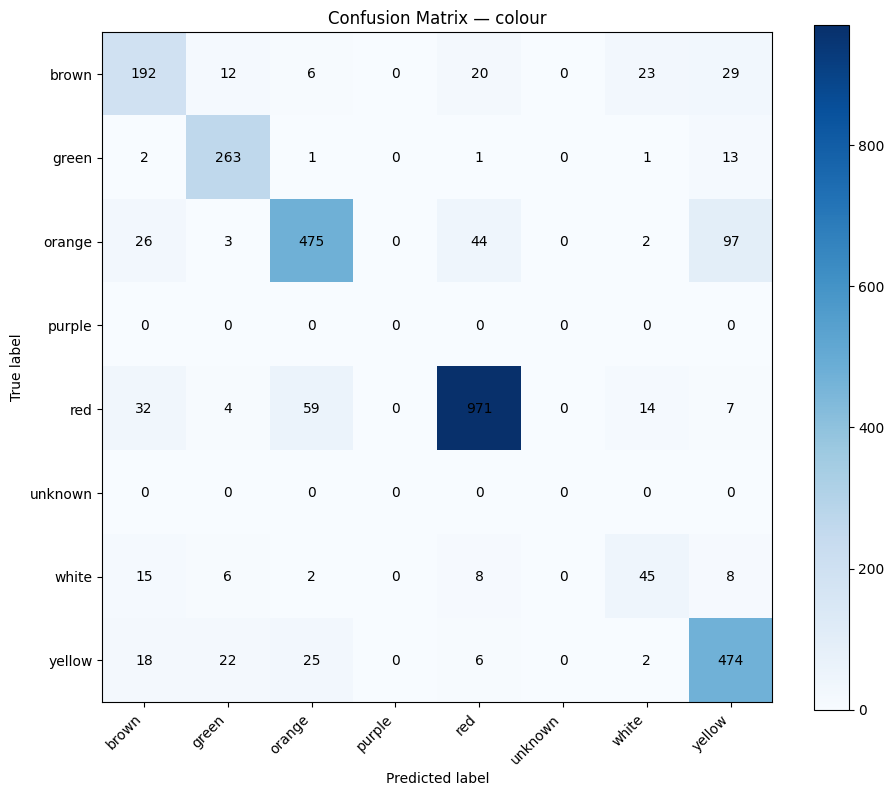


  SIZE
              precision    recall  f1-score   support

       large      0.704     0.766     0.734       736
      medium      0.781     0.828     0.804      1456
       small      0.830     0.659     0.735       736

    accuracy                          0.770      2928
   macro avg      0.772     0.751     0.757      2928
weighted avg      0.774     0.770     0.769      2928



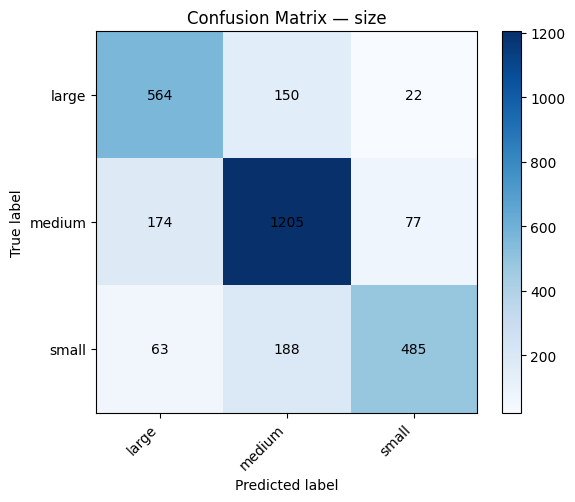


Evaluation complete.


In [4]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
except ImportError:
    _HAS_SEABORN = False

print("Loading test data...")
X_test      = np.load("X_test.npy")
y_cond_test = np.load("y_cond_test.npy")
y_col_test  = np.load("y_col_test.npy")
y_size_test = np.load("y_size_test.npy")

with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

print("Loading model...")
model = tf.keras.models.load_model("best_model.keras")

print(f"Running predictions on {len(X_test)} test samples...")
preds = model.predict(X_test, batch_size=32, verbose=1)

cond_pred = np.argmax(preds[0], axis=1)
col_pred  = np.argmax(preds[1], axis=1)
size_pred = np.argmax(preds[2], axis=1)

tasks = [
    ("condition", y_cond_test, cond_pred),
    ("colour",    y_col_test,  col_pred),
    ("size",      y_size_test, size_pred),
]

for task, y_true, y_pred in tasks:
    classes = list(encoders[task].classes_)
    labels  = list(range(len(classes)))
    print(f"\n{'='*50}")
    print(f"  {task.upper()}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, labels=labels, target_names=classes, digits=3))

    cm  = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(max(6, len(classes) * 1.2), max(5, len(classes))))

    if _HAS_SEABORN:
        sns.heatmap(cm, annot=True, fmt="d",
                    xticklabels=classes, yticklabels=classes,
                    cmap="Blues", ax=ax)
    else:
        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(classes)))
        ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha="right")
        ax.set_yticklabels(classes)
        for i in range(len(classes)):
            for j in range(len(classes)):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
        plt.colorbar(im, ax=ax)

    ax.set_title(f"Confusion Matrix — {task}")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{task}.png", dpi=150)
    plt.show()

print("\nEvaluation complete.")